# European Soccer Match Analytics: Data Pipeline & Feature Engineering

**Dataset:** [European Soccer Database](https://www.kaggle.com/datasets/hugomathien/soccer) (Kaggle, `hugomathien/soccer`)

This notebook builds an end-to-end data pipeline for the European Soccer Database, covering **25,979 matches**, **11,060 players**, and **299 teams** across 11 European leagues (2008-2016).

**Pipeline stages:**
1. Programmatic data acquisition via the Kaggle API (`kagglehub`)
2. SQLite → CSV extraction and DataFrame loading
3. Data quality assessment and missing-value handling
4. Match outcome labeling (win / draw / loss)
5. Feature extraction from embedded match-event XML (possession, shots, fouls, cards)
6. Consolidation into a single, model-ready match-level dataset

**Goal:** produce a clean, feature-rich dataset suitable for exploratory analysis and downstream predictive modeling of match outcomes.


## 0. Setup

All libraries used throughout the notebook are imported once here, following standard project conventions.

In [1]:
import os
import glob
import sqlite3
import xml.etree.ElementTree as ET

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 110
pd.set_option("display.max_columns", 50)


## 1. Data Acquisition (Kaggle API)

Instead of downloading the dataset manually, we pull it directly from Kaggle using `kagglehub`. This keeps the pipeline fully reproducible — anyone who clones the repository and has a valid Kaggle API token can re-run this notebook end-to-end without touching any external files by hand.

In [2]:
print("Step 1: Querying Kaggle for the latest dataset version...")
try:
    dataset_cache_path = kagglehub.dataset_download("hugomathien/soccer")
    print(f"Dataset located in cache at: {dataset_cache_path}")
except Exception as e:
    raise RuntimeError(f"Failed to download the dataset via kagglehub: {e}")

db_file_path = os.path.join(dataset_cache_path, "database.sqlite")

if not os.path.exists(db_file_path):
    raise FileNotFoundError(f"Expected database.sqlite was not found in: {dataset_cache_path}")

db_size_mb = os.path.getsize(db_file_path) / (1024 * 1024)
print(f"Verified 'database.sqlite' ({db_size_mb:.2f} MB)")


Step 1: Querying Kaggle for the latest dataset version...


100%|██████████| 32.7M/32.7M [00:00<00:00, 56.9MB/s]

Extracting files...


Dataset located in cache at: /root/.cache/kagglehub/datasets/hugomathien/soccer/versions/10
Verified 'database.sqlite' (298.59 MB)


## 2. Extracting SQLite Tables to CSV

The source data ships as a single SQLite database. We enumerate every table and export each one to its own CSV file under `soccer_csv_data/`, so the rest of the pipeline can work with plain DataFrames.

In [3]:
output_dir = "soccer_csv_data"
os.makedirs(output_dir, exist_ok=True)

print(f"Step 2: Unpacking SQLite tables to './{output_dir}'...")
print("-" * 65)

try:
    conn = sqlite3.connect(db_file_path)
    cursor = conn.cursor()

    cursor.execute("SELECT name FROM sqlite_master WHERE type='table';")
    tables = [row[0] for row in cursor.fetchall() if row[0] != 'sqlite_sequence']

    for table in tables:
        df = pd.read_sql_query(f"SELECT * FROM {table}", conn)
        csv_path = os.path.join(output_dir, f"{table}.csv")
        df.to_csv(csv_path, index=False)
        print(f"   Saved Table: {table:<20} -> {csv_path:<30} ({df.shape[0]:,} rows)")

    print("-" * 65)
    print("All tables extracted successfully.")

except sqlite3.Error as e:
    raise RuntimeError(f"Database error during extraction: {e}")
finally:
    if 'conn' in locals():
        conn.close()


Step 2: Unpacking SQLite tables to './soccer_csv_data'...
-----------------------------------------------------------------
   Saved Table: Player_Attributes    -> soccer_csv_data/Player_Attributes.csv (183,978 rows)
   Saved Table: Player               -> soccer_csv_data/Player.csv     (11,060 rows)
   Saved Table: Match                -> soccer_csv_data/Match.csv      (25,979 rows)
   Saved Table: League               -> soccer_csv_data/League.csv     (11 rows)
   Saved Table: Country              -> soccer_csv_data/Country.csv    (11 rows)
   Saved Table: Team                 -> soccer_csv_data/Team.csv       (299 rows)
   Saved Table: Team_Attributes      -> soccer_csv_data/Team_Attributes.csv (1,458 rows)
-----------------------------------------------------------------
All tables extracted successfully.


## 3. Loading Tables into DataFrames

Every extracted CSV is loaded into a `dataframes` dictionary, keyed by table name. This is the single source of truth used by every subsequent cleaning and feature-engineering step below — no table is ever re-read from disk twice.

In [4]:
print("Step 3: Loading generated CSVs into Pandas DataFrames...")
print("-" * 65)

csv_files = glob.glob(os.path.join(output_dir, "*.csv"))
dataframes = {}

for file_path in csv_files:
    table_name = os.path.basename(file_path).replace(".csv", "")
    dataframes[table_name] = pd.read_csv(file_path)

    mem_mb = dataframes[table_name].memory_usage(deep=True).sum() / (1024 * 1024)
    print(f"   Loaded: {table_name:<20} | Memory Allocation: {mem_mb:6.2f} MB")

print("-" * 65)
print("Ready! Tables are accessible via dataframes['TableName'].")


Step 3: Loading generated CSVs into Pandas DataFrames...
-----------------------------------------------------------------
   Loaded: Country              | Memory Allocation:   0.00 MB
   Loaded: Player_Attributes    | Memory Allocation:  93.57 MB
   Loaded: Team                 | Memory Allocation:   0.04 MB
   Loaded: Team_Attributes      | Memory Allocation:   1.15 MB
   Loaded: Match                | Memory Allocation: 288.52 MB
   Loaded: Player               | Memory Allocation:   1.80 MB
   Loaded: League               | Memory Allocation:   0.00 MB
-----------------------------------------------------------------
Ready! Tables are accessible via dataframes['TableName'].


## 4. Data Quality Assessment & Cleaning

Each table is checked for missing values and cleaned with a consistent rule:

- **Numeric columns** → filled with the column **median** (robust to outliers)
- **Categorical columns** → filled with the column **mode**
- Columns that are missing for the large majority of rows are dropped instead of imputed, since imputation would fabricate signal that isn't there

### 4.1 `Player`
No missing-value handling is required — the check below confirms the table is already complete.

In [5]:
player = dataframes['Player']
print("Missing values in Player table:")
print(player.isnull().sum())


Missing values in Player table:
id                    0
player_api_id         0
player_name           0
player_fifa_api_id    0
birthday              0
height                0
weight                0
dtype: int64


### 4.2 `Player_Attributes`

Applying the median/mode imputation rule column-by-column.

In [6]:
player_attr = dataframes['Player_Attributes']
player_attr.info()

fill_rules = {
    col: (player_attr[col].median() if player_attr[col].dtype != 'object' else player_attr[col].mode()[0])
    for col in player_attr.columns
}
player_attr = player_attr.fillna(value=fill_rules)

print("\nRemaining missing values after imputation:")
print(player_attr.isnull().sum())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 183978 entries, 0 to 183977
Data columns (total 42 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   id                   183978 non-null  int64  
 1   player_fifa_api_id   183978 non-null  int64  
 2   player_api_id        183978 non-null  int64  
 3   date                 183978 non-null  object 
 4   overall_rating       183142 non-null  float64
 5   potential            183142 non-null  float64
 6   preferred_foot       183142 non-null  object 
 7   attacking_work_rate  177109 non-null  object 
 8   defensive_work_rate  183142 non-null  object 
 9   crossing             183142 non-null  float64
 10  finishing            183142 non-null  float64
 11  heading_accuracy     183142 non-null  float64
 12  short_passing        183142 non-null  float64
 13  volleys              181265 non-null  float64
 14  dribbling            183142 non-null  float64
 15  curve            

### 4.3 `Team`

Only `team_fifa_api_id` has missing values; imputed with the column median.

In [7]:
team = dataframes['Team']
team.info()
team['team_fifa_api_id'] = team['team_fifa_api_id'].fillna(team['team_fifa_api_id'].median())
print("\nRemaining missing values:")
print(team.isnull().sum())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 299 entries, 0 to 298
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   id                299 non-null    int64  
 1   team_api_id       299 non-null    int64  
 2   team_fifa_api_id  288 non-null    float64
 3   team_long_name    299 non-null    object 
 4   team_short_name   299 non-null    object 
dtypes: float64(1), int64(2), object(2)
memory usage: 11.8+ KB

Remaining missing values:
id                  0
team_api_id         0
team_fifa_api_id    0
team_long_name      0
team_short_name     0
dtype: int64


### 4.4 `Team_Attributes`

`buildUpPlayDribbling` is missing for a large share of rows and is dropped rather than imputed.

In [8]:
team_attr = dataframes['Team_Attributes']
team_attr.info()
team_attr = team_attr.drop(columns=['buildUpPlayDribbling'])
print("\nRemaining missing values:")
print(team_attr.isnull().sum())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1458 entries, 0 to 1457
Data columns (total 25 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              1458 non-null   int64  
 1   team_fifa_api_id                1458 non-null   int64  
 2   team_api_id                     1458 non-null   int64  
 3   date                            1458 non-null   object 
 4   buildUpPlaySpeed                1458 non-null   int64  
 5   buildUpPlaySpeedClass           1458 non-null   object 
 6   buildUpPlayDribbling            489 non-null    float64
 7   buildUpPlayDribblingClass       1458 non-null   object 
 8   buildUpPlayPassing              1458 non-null   int64  
 9   buildUpPlayPassingClass         1458 non-null   object 
 10  buildUpPlayPositioningClass     1458 non-null   object 
 11  chanceCreationPassing           1458 non-null   int64  
 12  chanceCreationPassingClass      14

### 4.5 `Match`

The `Match` table contains many optional columns (betting odds, match-event XML). Non-critical numeric/categorical gaps are imputed with the same median/mode rule; the XML event columns are handled separately in Section 6, since they require parsing rather than imputation.

In [9]:
match = dataframes['Match']
match.info()
null_summary = match.isnull().sum()
print("\nColumns with missing values:")
print(null_summary[null_summary > 0].sort_values(ascending=False))

fill_rules = {}
for col in match.columns:
    if match[col].dtype != 'object':
        fill_rules[col] = match[col].median()
    else:
        fill_rules[col] = match[col].mode()[0]
match = match.fillna(value=fill_rules)

remaining_nulls = match.isnull().sum()
print(f"\nColumns still containing nulls after imputation: {len(remaining_nulls[remaining_nulls > 0])}")


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25979 entries, 0 to 25978
Columns: 115 entries, id to BSA
dtypes: float64(96), int64(9), object(10)
memory usage: 22.8+ MB

Columns with missing values:
PSA              14811
PSD              14811
PSH              14811
BSH              11818
BSD              11818
                 ...  
home_player_9     1273
away_player_7     1235
away_player_1     1234
home_player_7     1227
home_player_1     1224
Length: 104, dtype: int64

Columns still containing nulls after imputation: 0


### 4.6 `Country` and `League`

Both are small reference tables; confirming they are already complete.

In [10]:
country = dataframes['Country']
league = dataframes['League']

print("Missing values in Country:")
print(country.isnull().sum())
print("\nMissing values in League:")
print(league.isnull().sum())


Missing values in Country:
id      0
name    0
dtype: int64

Missing values in League:
id            0
country_id    0
name          0
dtype: int64


## 5. Feature Engineering: Match Outcome Labels

From the raw goal counts we derive the target variables used for outcome analysis and modeling: goal difference, and one-hot win/draw indicators.

In [11]:
match['goal_difference'] = match['home_team_goal'] - match['away_team_goal']
match['home_win'] = (match['goal_difference'] > 0).astype(int)
match['away_win'] = (match['goal_difference'] < 0).astype(int)
match['draw'] = (match['goal_difference'] == 0).astype(int)

print("Match outcome distribution:")
print(pd.Series({
    'Home wins': match['home_win'].sum(),
    'Away wins': match['away_win'].sum(),
    'Draws': match['draw'].sum(),
}))


Match outcome distribution:
Home wins    11917
Away wins     7466
Draws         6596
dtype: int64


/tmp/ipykernel_4865/1633263035.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  match['goal_difference'] = match['home_team_goal'] - match['away_team_goal']
/tmp/ipykernel_4865/1633263035.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  match['home_win'] = (match['goal_difference'] > 0).astype(int)
/tmp/ipykernel_4865/1633263035.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using p

## 6. Feature Extraction from Match-Event XML: Possession & Shots

Several `Match` columns (`possession`, `shoton`, `shotoff`, ...) store raw event-by-event data as XML strings rather than plain numbers. We parse each match's XML blob to extract:

- **`home_possession`** — the final recorded home-team possession percentage
- **`total_shots_on`** — count of on-target shot events
- **`total_shots_off`** — count of off-target shot events

Results are assigned back to `match` via a single `pd.concat`, avoiding the fragmented-DataFrame performance warning that repeated column-by-column assignment would trigger.

In [12]:
def extract_possession_and_shots(row):
    possession = np.nan
    shots_on = 0
    shots_off = 0

    if pd.notnull(row['possession']) and row['possession'] != "Unknown":
        try:
            root = ET.fromstring(row['possession'])
            values = root.findall('.//value')
            if values:
                homepos = values[-1].find('homepos')
                if homepos is not None:
                    possession = float(homepos.text)
        except ET.ParseError:
            pass

    if pd.notnull(row['shoton']) and row['shoton'] != "Unknown":
        try:
            shots_on = len(ET.fromstring(row['shoton']).findall('.//value'))
        except ET.ParseError:
            pass

    if pd.notnull(row['shotoff']) and row['shotoff'] != "Unknown":
        try:
            shots_off = len(ET.fromstring(row['shotoff']).findall('.//value'))
        except ET.ParseError:
            pass

    return pd.Series(
        [possession, shots_on, shots_off],
        index=['home_possession', 'total_shots_on', 'total_shots_off']
    )

shot_features = match.apply(extract_possession_and_shots, axis=1)
match = pd.concat([match, shot_features], axis=1)

match[['home_possession', 'total_shots_on', 'total_shots_off']].describe()


,home_possession,total_shots_on,total_shots_off
count,8417.000000,25979.000000,25979.000000
mean,51.495901,6.917857,6.917703
std,9.305520,12.622504,12.301140
min,4.000000,0.000000,0.000000
25%,45.000000,0.000000,0.000000
50%,52.000000,0.000000,0.000000
75%,58.000000,10.000000,11.000000
max,83.000000,78.000000,75.000000


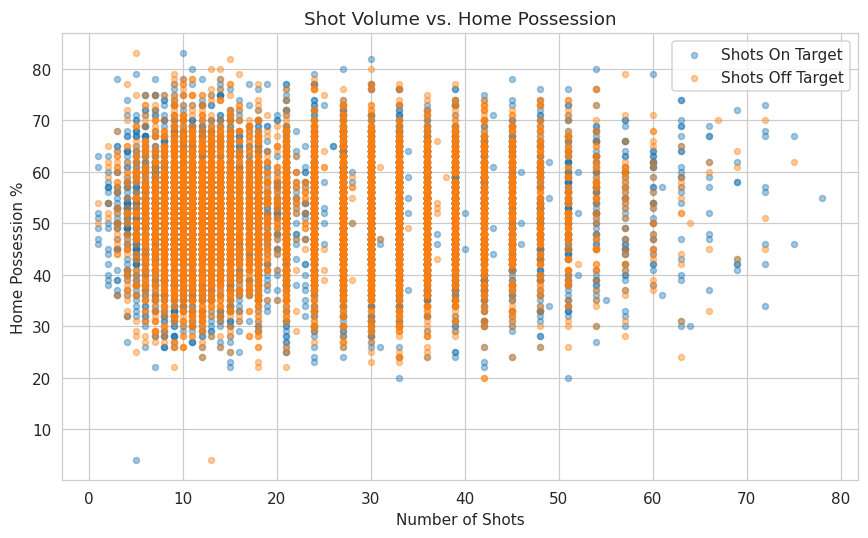

In [13]:
plot_data = match.dropna(subset=['home_possession'])

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(plot_data['total_shots_on'], plot_data['home_possession'],
           label='Shots On Target', color='#1f77b4', alpha=0.4, s=15)
ax.scatter(plot_data['total_shots_off'], plot_data['home_possession'],
           label='Shots Off Target', color='#ff7f0e', alpha=0.4, s=15)
ax.set_ylabel('Home Possession %')
ax.set_xlabel('Number of Shots')
ax.set_title('Shot Volume vs. Home Possession')
ax.legend()
plt.tight_layout()
plt.show()


## 7. Feature Extraction from Match-Event XML: Fouls & Cards

The same event-log pattern is used to extract per-team foul and card counts from the `foulcommit` and `card` XML columns, attributing each event to the home or away team by matching `team_api_id`.

In [14]:
def extract_fouls_and_cards(row):
    home_fouls, away_fouls = 0, 0
    home_cards, away_cards = 0, 0

    home_team_id = str(row['home_team_api_id'])
    away_team_id = str(row['away_team_api_id'])

    if pd.notnull(row['foulcommit']) and row['foulcommit'] != "Unknown":
        try:
            for value in ET.fromstring(row['foulcommit']).findall('.//value'):
                team_node = value.find('team')
                if team_node is not None:
                    if team_node.text == home_team_id:
                        home_fouls += 1
                    elif team_node.text == away_team_id:
                        away_fouls += 1
        except ET.ParseError:
            pass

    if pd.notnull(row['card']) and row['card'] != "Unknown":
        try:
            for value in ET.fromstring(row['card']).findall('.//value'):
                team_node = value.find('team')
                if team_node is not None:
                    if team_node.text == home_team_id:
                        home_cards += 1
                    elif team_node.text == away_team_id:
                        away_cards += 1
        except ET.ParseError:
            pass

    return pd.Series(
        [home_fouls, away_fouls, home_cards, away_cards],
        index=['home_fouls', 'away_fouls', 'home_cards', 'away_cards']
    )

print("Parsing XML for fouls and cards... (this can take 10-15 seconds)")
foul_card_features = match.apply(extract_fouls_and_cards, axis=1)
match = pd.concat([match, foul_card_features], axis=1)

valid_foul_data = match[(match['home_fouls'] > 0) | (match['away_fouls'] > 0)]
print(f"Matches with recorded foul events: {len(valid_foul_data):,} / {len(match):,}")


Parsing XML for fouls and cards... (this can take 10-15 seconds)
Matches with recorded foul events: 8,465 / 25,979


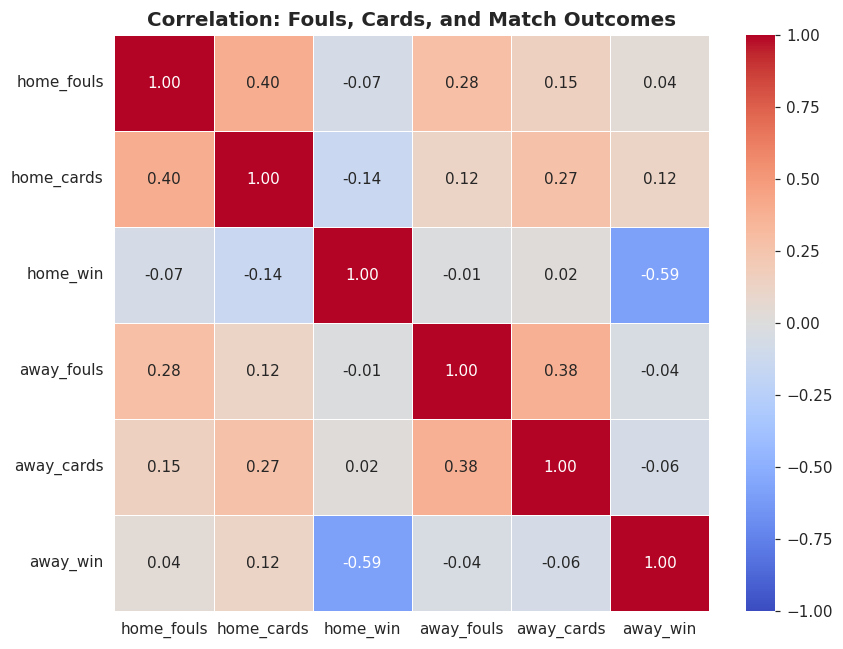

In [15]:
correlation_cols = [
    'home_fouls', 'home_cards', 'home_win',
    'away_fouls', 'away_cards', 'away_win'
]
corr_matrix = valid_foul_data[correlation_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1,
            fmt=".2f", linewidths=0.5)
plt.title('Correlation: Fouls, Cards, and Match Outcomes', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


## 8. Building the Consolidated Master Dataset

Finally, we join match-level context (country, league, team names, and each team's average build-up speed/pressure from `Team_Attributes`) with the engineered outcome and event features from Sections 5-7, producing a single, model-ready table.

In [16]:
sql_query = """
WITH AggregatedTeamAttributes AS (
    SELECT
        team_api_id,
        AVG(buildUpPlaySpeed) AS avg_speed,
        AVG(defencePressure) AS avg_pressure
    FROM Team_Attributes
    GROUP BY team_api_id
)
SELECT
    m.match_api_id,
    m.date,
    c.name AS country_name,
    l.name AS league_name,
    ht.team_long_name AS home_team_name,
    at.team_long_name AS away_team_name,
    m.home_team_goal,
    m.away_team_goal,
    ha.avg_speed AS home_team_buildup_speed,
    ha.avg_pressure AS home_team_defence_pressure,
    aa.avg_speed AS away_team_buildup_speed,
    aa.avg_pressure AS away_team_defence_pressure
FROM Match m
JOIN Country c ON m.country_id = c.id
JOIN League l ON m.league_id = l.id
JOIN Team ht ON m.home_team_api_id = ht.team_api_id
JOIN Team at ON m.away_team_api_id = at.team_api_id
LEFT JOIN AggregatedTeamAttributes ha ON m.home_team_api_id = ha.team_api_id
LEFT JOIN AggregatedTeamAttributes aa ON m.away_team_api_id = aa.team_api_id;
"""

print("Connecting to database and running consolidation query...")
try:
    conn = sqlite3.connect(db_file_path)
    master_df = pd.read_sql_query(sql_query, conn)
    print(f"Success. Base master dataset: {master_df.shape[0]:,} rows x {master_df.shape[1]} columns")
except sqlite3.Error as e:
    raise RuntimeError(f"Database error: {e}")
finally:
    if 'conn' in locals():
        conn.close()

engineered_cols = [
    'match_api_id', 'goal_difference', 'home_win', 'away_win', 'draw',
    'home_possession', 'total_shots_on', 'total_shots_off',
    'home_fouls', 'away_fouls', 'home_cards', 'away_cards'
]
master_df = master_df.merge(match[engineered_cols], on='match_api_id', how='left')

print(f"Final consolidated dataset: {master_df.shape[0]:,} rows x {master_df.shape[1]} columns")
master_df.head()


Connecting to database and running consolidation query...
Success. Base master dataset: 25,979 rows x 12 columns
Final consolidated dataset: 25,979 rows x 23 columns


,match_api_id,date,country_name,league_name,home_team_name,away_team_name,home_team_goal,away_team_goal,home_team_buildup_speed,home_team_defence_pressure,away_team_buildup_speed,away_team_defence_pressure,goal_difference,home_win,away_win,draw,home_possession,total_shots_on,total_shots_off,home_fouls,away_fouls,home_cards,away_cards
0,492473,2008-08-17 00:00:00,Belgium,Belgium Jupiler League,KRC Genk,Beerschot AC,1,1,56.333333,49.166667,46.000000,48.250000,0,0,0,1,NaN,0.0,0.0,0,0,0,0
1,492474,2008-08-16 00:00:00,Belgium,Belgium Jupiler League,SV Zulte-Waregem,Sporting Lokeren,0,0,55.500000,48.666667,64.000000,48.833333,0,0,0,1,NaN,0.0,0.0,0,0,0,0
2,492475,2008-08-16 00:00:00,Belgium,Belgium Jupiler League,KSV Cercle Brugge,RSC Anderlecht,0,3,53.666667,60.166667,51.333333,59.666667,-3,0,1,0,NaN,0.0,0.0,0,0,0,0
3,492476,2008-08-17 00:00:00,Belgium,Belgium Jupiler League,KAA Gent,RAEC Mons,5,0,54.166667,51.333333,51.666667,46.000000,5,1,0,0,NaN,0.0,0.0,0,0,0,0
4,492477,2008-08-16 00:00:00,Belgium,Belgium Jupiler League,FCV Dender EH,Standard de Liège,1,3,NaN,NaN,59.666667,51.500000,-2,0,1,0,NaN,0.0,0.0,0,0,0,0


In [17]:
os.makedirs("data/processed", exist_ok=True)
output_path = "data/processed/soccer_match_master.csv"
master_df.to_csv(output_path, index=False)
print(f"Saved final dataset to: {output_path}")


Saved final dataset to: data/processed/soccer_match_master.csv


## 10. What Is the Distribution of Goals Scored in Matches?

Before looking at trends over time, it's worth understanding the basic shape of scoring in this dataset: how many goals does a typical match produce, and how does home scoring compare to away scoring?

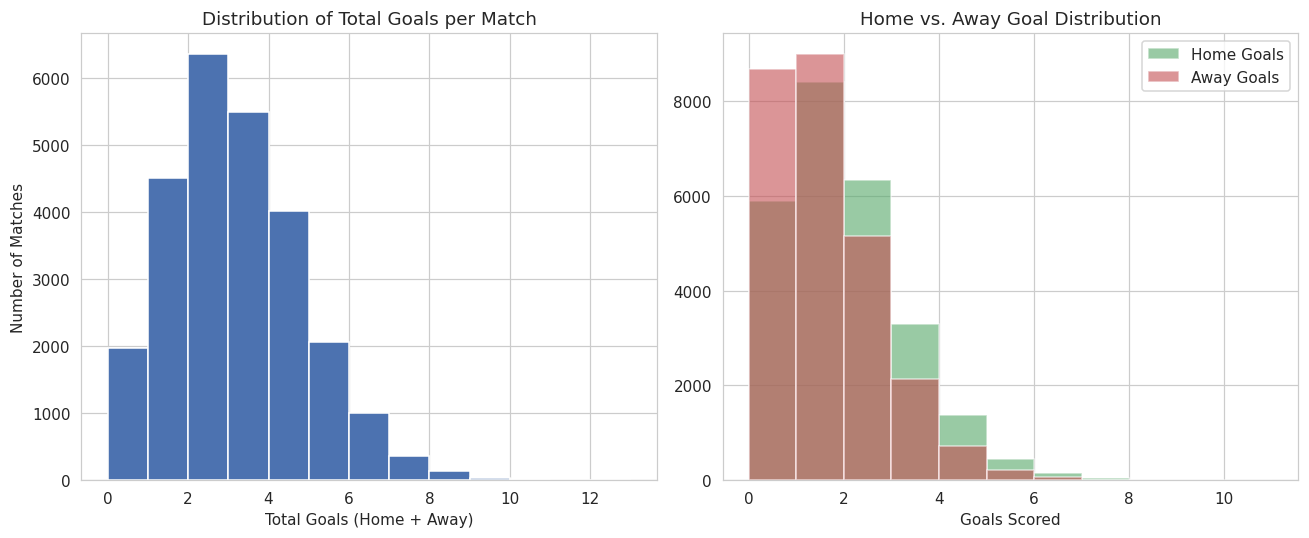

,total_goals
count,25979.000000
mean,2.705531
std,1.672456
min,0.000000
25%,2.000000
50%,3.000000
75%,4.000000
max,12.000000


In [18]:
match['total_goals'] = match['home_team_goal'] + match['away_team_goal']

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].hist(match['total_goals'], bins=range(0, match['total_goals'].max() + 2),
             color='#4C72B0', edgecolor='white')
axes[0].set_title('Distribution of Total Goals per Match')
axes[0].set_xlabel('Total Goals (Home + Away)')
axes[0].set_ylabel('Number of Matches')

axes[1].hist(match['home_team_goal'], bins=range(0, match['home_team_goal'].max() + 2),
             alpha=0.6, label='Home Goals', color='#55A868')
axes[1].hist(match['away_team_goal'], bins=range(0, match['away_team_goal'].max() + 2),
             alpha=0.6, label='Away Goals', color='#C44E52')
axes[1].set_title('Home vs. Away Goal Distribution')
axes[1].set_xlabel('Goals Scored')
axes[1].legend()

plt.tight_layout()
plt.show()

match['total_goals'].describe()


## 11. Monthly Trends Analysis

How do match outcomes — total goals scored and the home-team win rate — vary across different months of the year? We extract the calendar month from each match date and aggregate.

In [19]:
match['date'] = pd.to_datetime(match['date'])
match['match_month'] = match['date'].dt.month
match['match_year_month'] = match['date'].dt.to_period('M')

monthly_trends = match.groupby('match_month').agg(
    avg_total_goals=('total_goals', 'mean'),
    home_win_rate=('home_win', 'mean'),
    matches_played=('match_api_id', 'count')
).reset_index()

monthly_trends


,match_month,avg_total_goals,home_win_rate,matches_played
0,1,2.666514,0.468621,2183
1,2,2.628088,0.458010,2834
2,3,2.620467,0.466427,2785
3,4,2.743348,0.459414,2969
4,5,2.853898,0.466370,2245
5,6,3.652174,0.565217,23
6,7,2.733945,0.454128,218
7,8,2.630931,0.425308,2276
8,9,2.744078,0.455534,2575
9,10,2.730061,0.468942,2608


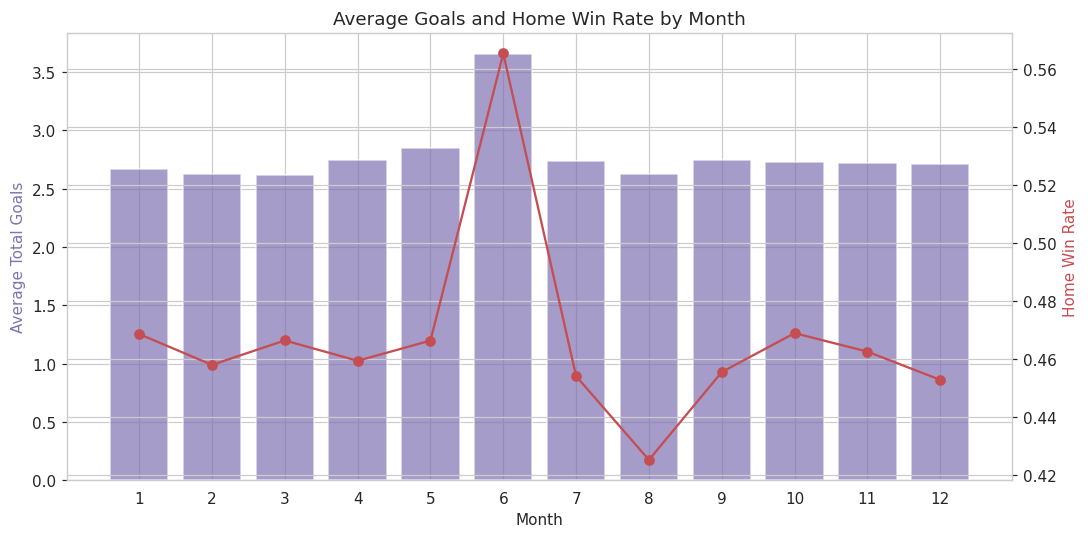

In [20]:
fig, ax1 = plt.subplots(figsize=(10, 5))

ax1.bar(monthly_trends['match_month'], monthly_trends['avg_total_goals'],
        color='#8172B2', alpha=0.7, label='Avg Goals / Match')
ax1.set_xlabel('Month')
ax1.set_ylabel('Average Total Goals', color='#8172B2')
ax1.set_xticks(range(1, 13))

ax2 = ax1.twinx()
ax2.plot(monthly_trends['match_month'], monthly_trends['home_win_rate'],
         color='#C44E52', marker='o', label='Home Win Rate')
ax2.set_ylabel('Home Win Rate', color='#C44E52')

plt.title('Average Goals and Home Win Rate by Month')
fig.tight_layout()
plt.show()


## 12. Time Series Visualizations

This section covers three complementary views of the data over time:

- The **overall seasonal/monthly trend** in scoring across the full 2008-2016 timeline
- A **team-level time series**, tracking cumulative home goals for the most active teams across match dates
- A **comparative bar chart across leagues** ("tournament types"), since each league behaves like its own competitive environment

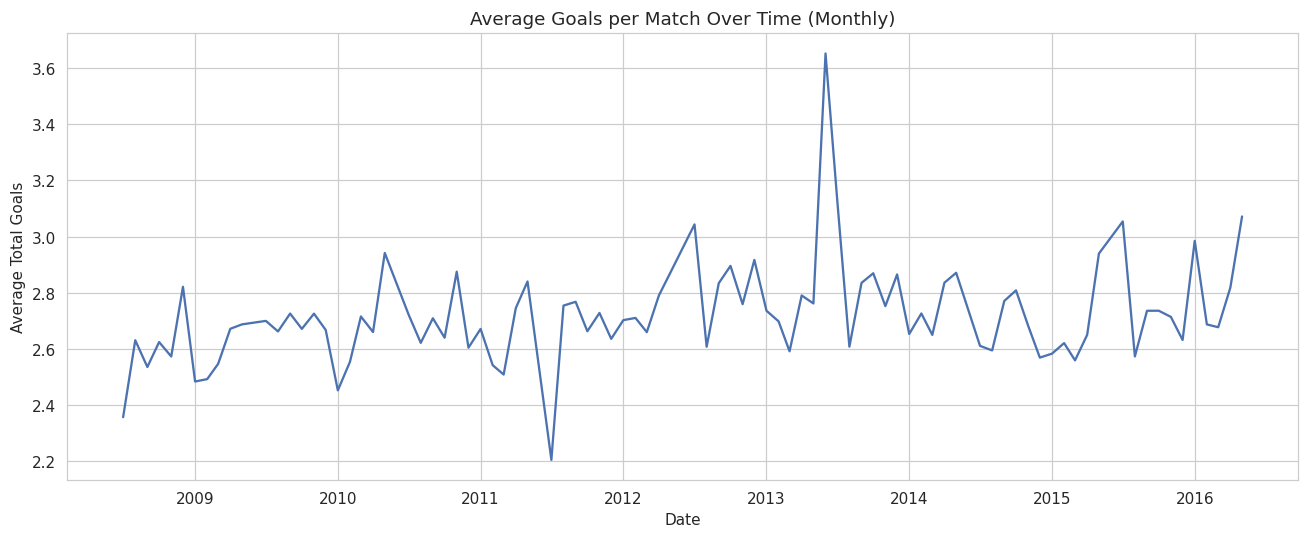

In [21]:
season_trend = match.groupby('match_year_month').agg(
    avg_total_goals=('total_goals', 'mean'),
    matches_played=('match_api_id', 'count')
).reset_index()
season_trend['match_year_month'] = season_trend['match_year_month'].dt.to_timestamp()

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(season_trend['match_year_month'], season_trend['avg_total_goals'], color='#4C72B0')
ax.set_title('Average Goals per Match Over Time (Monthly)')
ax.set_xlabel('Date')
ax.set_ylabel('Average Total Goals')
plt.tight_layout()
plt.show()


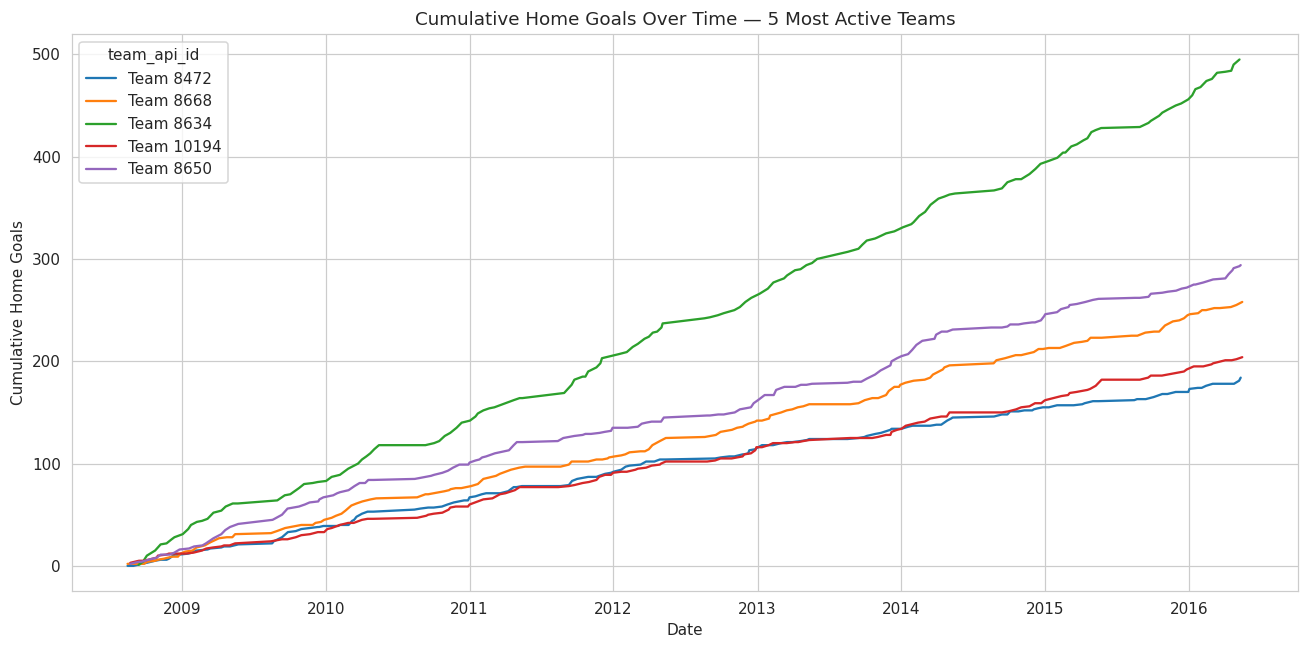

In [22]:
top_teams = match['home_team_api_id'].value_counts().head(5).index

fig, ax = plt.subplots(figsize=(12, 6))
for team_id in top_teams:
    team_matches = match[match['home_team_api_id'] == team_id].sort_values('date')
    ax.plot(team_matches['date'], team_matches['home_team_goal'].cumsum(), label=f'Team {team_id}')

ax.set_title('Cumulative Home Goals Over Time — 5 Most Active Teams')
ax.set_xlabel('Date')
ax.set_ylabel('Cumulative Home Goals')
ax.legend(title='team_api_id')
plt.tight_layout()
plt.show()


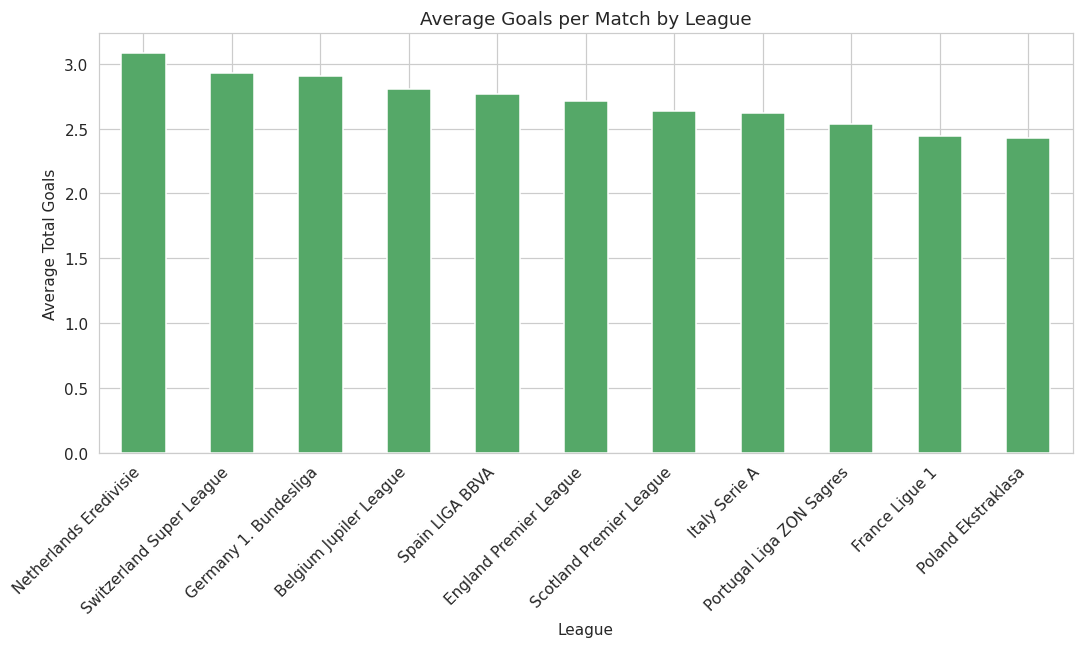

In [23]:
master_df['total_goals'] = master_df['home_team_goal'] + master_df['away_team_goal']
league_goals = master_df.groupby('league_name')['total_goals'].mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
league_goals.plot(kind='bar', ax=ax, color='#55A868')
ax.set_title('Average Goals per Match by League')
ax.set_ylabel('Average Total Goals')
ax.set_xlabel('League')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


## 13. Performance Visualizations

Finally, we highlight top performers and use box plots to compare distributions across categories and flag outliers.

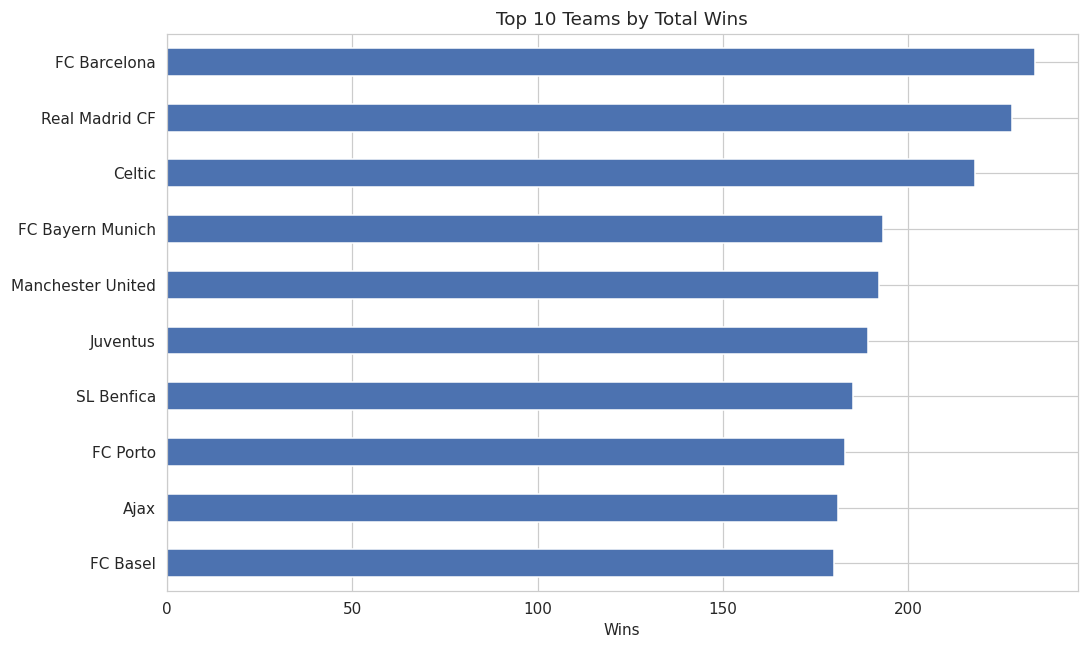

In [24]:
team_wins = pd.concat([
    master_df.loc[master_df['home_win'] == 1, 'home_team_name'],
    master_df.loc[master_df['away_win'] == 1, 'away_team_name']
]).value_counts().head(10)

fig, ax = plt.subplots(figsize=(10, 6))
team_wins.sort_values().plot(kind='barh', ax=ax, color='#4C72B0')
ax.set_title('Top 10 Teams by Total Wins')
ax.set_xlabel('Wins')
plt.tight_layout()
plt.show()


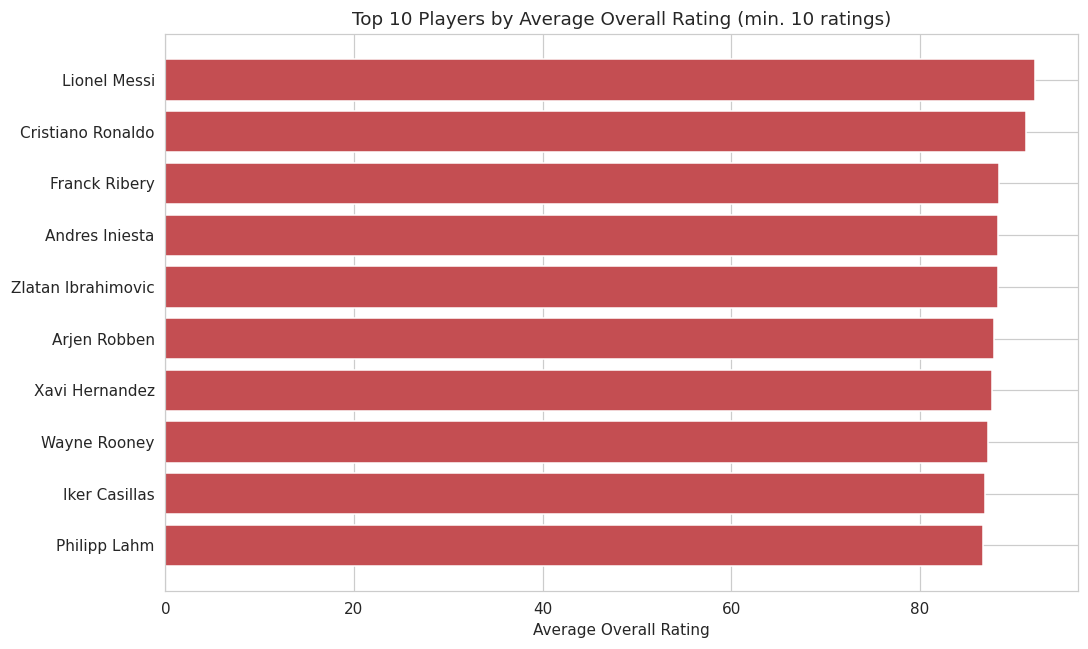

In [25]:
player_ratings = player_attr.groupby('player_api_id')['overall_rating'].mean()
rating_counts = player_attr.groupby('player_api_id')['overall_rating'].count()
qualified_players = player_ratings[rating_counts >= 10]

top_players = (
    qualified_players.sort_values(ascending=False).head(10)
    .rename_axis('player_api_id').reset_index()
    .merge(player[['player_api_id', 'player_name']], on='player_api_id', how='left')
)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(top_players['player_name'], top_players['overall_rating'], color='#C44E52')
ax.invert_yaxis()
ax.set_title('Top 10 Players by Average Overall Rating (min. 10 ratings)')
ax.set_xlabel('Average Overall Rating')
plt.tight_layout()
plt.show()


/tmp/ipykernel_4865/4047882735.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=master_df, x='league_name', y='total_goals', ax=ax, palette='Set2')


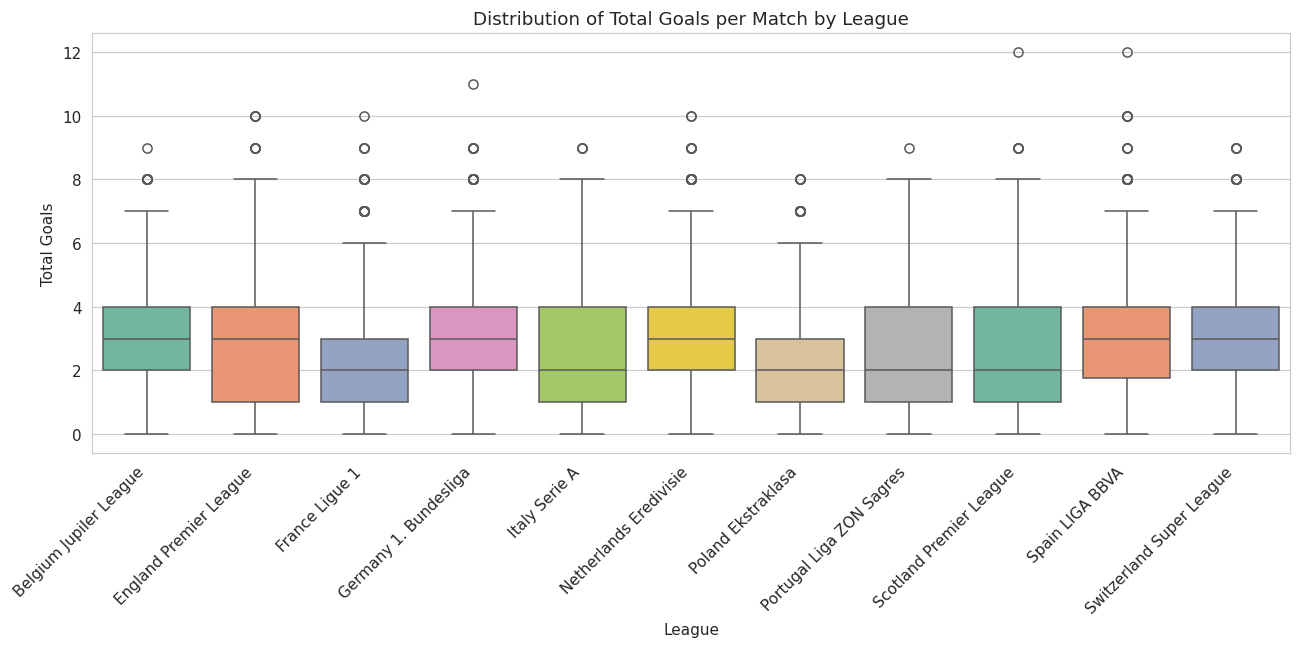

In [26]:
fig, ax = plt.subplots(figsize=(12, 6))
sns.boxplot(data=master_df, x='league_name', y='total_goals', ax=ax, palette='Set2')
ax.set_title('Distribution of Total Goals per Match by League')
ax.set_xlabel('League')
ax.set_ylabel('Total Goals')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


Matches with unusually high scorelines (> 7.0 total goals): 192


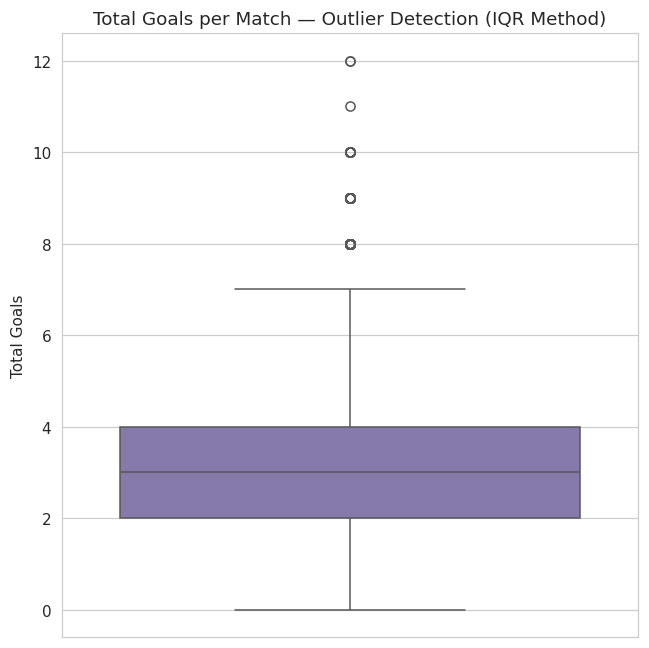

,date,home_team_api_id,away_team_api_id,home_team_goal,away_team_goal,total_goals
20106,2010-05-05,9927,10251,6,6,12
24247,2015-12-20,8633,8370,10,2,12
9210,2013-03-30,9823,9790,9,2,11
2156,2009-11-22,8586,8528,9,1,10
5191,2009-11-08,9748,8592,5,5,10
3092,2011-08-28,10260,9825,8,2,10
3565,2013-05-19,8659,10260,5,5,10
3368,2012-12-29,9825,10261,7,3,10
24113,2015-05-23,8633,8305,7,3,10
14223,2011-11-06,9908,8593,6,4,10


In [27]:
q1 = match['total_goals'].quantile(0.25)
q3 = match['total_goals'].quantile(0.75)
iqr = q3 - q1
upper_bound = q3 + 1.5 * iqr

outlier_matches = match[match['total_goals'] > upper_bound]
print(f"Matches with unusually high scorelines (> {upper_bound:.1f} total goals): {len(outlier_matches):,}")

fig, ax = plt.subplots(figsize=(6, 6))
sns.boxplot(y=match['total_goals'], ax=ax, color='#8172B2')
ax.set_title('Total Goals per Match — Outlier Detection (IQR Method)')
ax.set_ylabel('Total Goals')
plt.tight_layout()
plt.show()

outlier_matches[['date', 'home_team_api_id', 'away_team_api_id',
                  'home_team_goal', 'away_team_goal', 'total_goals']] \
    .sort_values('total_goals', ascending=False).head(10)


# Part II: Match Outcome Prediction

**Question:** Can we predict the outcome of a match (Home Win / Away Win / Draw) using only information available *before kickoff*?

This is a different problem from Part I. Everything above (possession, shots, fouls, cards) was extracted from post-match event data — useful for understanding what happened, but useless for prediction, since it doesn't exist until the match is already over. Using it as a feature would be **data leakage**: the model would appear highly accurate while secretly cheating off information it could never have in a real pre-match scenario.

So Part II rebuilds a feature set from scratch, using only:
- Team playing-style attributes, as of the most recent snapshot **before** the match date
- Rolling team form (win rate, goals scored/conceded) computed only from **past** matches
- Head-to-head history between the two specific teams, from **past** meetings only
- Starting-XI player ratings, using each player's most recent rating **before** the match date
- League and match stage

And it evaluates with a **time-based** train/test split (train on earlier seasons, test on later ones), since a random split would let the model implicitly learn from the "future."

## 15. Modeling Setup

Additional libraries needed for feature engineering and modeling.

In [28]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)

match_sorted = match.sort_values('date').reset_index(drop=True).copy()
print(f"Working with {len(match_sorted):,} matches, {match_sorted['date'].min().date()} to {match_sorted['date'].max().date()}")


Working with 25,979 matches, 2008-07-18 to 2016-05-25


## 16. Target Variable: `match_result`

Collapsing the existing `home_win` / `away_win` / `draw` indicator columns into a single three-class target.

In [29]:
def label_result(row):
    if row['home_win'] == 1:
        return 'Home Win'
    elif row['away_win'] == 1:
        return 'Away Win'
    return 'Draw'

match_sorted['match_result'] = match_sorted.apply(label_result, axis=1)
match_sorted['match_result'].value_counts(normalize=True).round(3)


,proportion
match_result,
Home Win,0.459
Away Win,0.287
Draw,0.254


## 17. Pre-Match Team Attributes

For each match, we attach each team's most recent `Team_Attributes` snapshot **strictly before** the match date, using `pd.merge_asof` — a time-aware join that looks backward instead of matching on exact keys. This guarantees no attribute values from after the match leak into the features.

In [30]:
team_attr_sorted = team_attr.sort_values('date').copy()
team_attr_sorted['date'] = pd.to_datetime(team_attr_sorted['date'])

style_cols = ['buildUpPlaySpeed', 'chanceCreationPassing', 'defencePressure']

def attach_team_style(match_df, team_id_col, prefix):
    temp = match_df[['match_api_id', 'date', team_id_col]].rename(columns={team_id_col: 'team_api_id'})
    temp = temp.sort_values('date')
    merged = pd.merge_asof(
        temp, team_attr_sorted[['team_api_id', 'date'] + style_cols],
        on='date', by='team_api_id', direction='backward'
    )
    merged = merged.rename(columns={c: f'{prefix}_{c}' for c in style_cols})
    return merged.set_index('match_api_id')[[f'{prefix}_{c}' for c in style_cols]]

home_style = attach_team_style(match_sorted, 'home_team_api_id', 'home')
away_style = attach_team_style(match_sorted, 'away_team_api_id', 'away')

match_sorted = match_sorted.merge(home_style, on=None, left_on='match_api_id', right_index=True, how='left')
match_sorted = match_sorted.merge(away_style, on=None, left_on='match_api_id', right_index=True, how='left')

match_sorted[[f'home_{c}' for c in style_cols] + [f'away_{c}' for c in style_cols]].describe()


,home_buildUpPlaySpeed,home_chanceCreationPassing,home_defencePressure,away_buildUpPlaySpeed,away_chanceCreationPassing,away_defencePressure
count,19916.000000,19916.000000,19916.000000,19924.000000,19924.000000,19924.000000
mean,52.419813,52.412482,46.479665,52.399368,52.409556,46.454828
std,11.931167,10.403592,10.213923,11.930144,10.398678,10.217531
min,20.000000,21.000000,23.000000,20.000000,21.000000,23.000000
25%,45.000000,47.000000,39.000000,45.000000,47.000000,39.000000
50%,52.000000,52.000000,46.000000,52.000000,52.000000,46.000000
75%,62.000000,60.000000,53.000000,62.000000,60.000000,53.000000
max,80.000000,80.000000,72.000000,80.000000,80.000000,72.000000


## 18. Rolling Team Form

For every team, we build a chronological match log (one row per team per match, home or away) and compute the win rate and average goals scored/conceded over each team's **previous 5 matches**. Shifting by one match before applying the rolling window ensures the current match is never included in its own form calculation.

In [31]:
home_log = match_sorted[['match_api_id', 'date', 'home_team_api_id', 'home_team_goal', 'away_team_goal', 'home_win']].rename(
    columns={'home_team_api_id': 'team_api_id', 'home_team_goal': 'goals_scored',
             'away_team_goal': 'goals_conceded', 'home_win': 'win'}
)
home_log['is_home'] = 1

away_log = match_sorted[['match_api_id', 'date', 'away_team_api_id', 'away_team_goal', 'home_team_goal', 'away_win']].rename(
    columns={'away_team_api_id': 'team_api_id', 'away_team_goal': 'goals_scored',
             'home_team_goal': 'goals_conceded', 'away_win': 'win'}
)
away_log['is_home'] = 0

team_log = pd.concat([home_log, away_log], ignore_index=True).sort_values(['team_api_id', 'date'])

for col, new_col in [('win', 'form_win_rate'), ('goals_scored', 'form_avg_scored'), ('goals_conceded', 'form_avg_conceded')]:
    team_log[new_col] = (
        team_log.groupby('team_api_id')[col]
        .transform(lambda s: s.shift(1).rolling(window=5, min_periods=1).mean())
    )

form_cols = ['form_win_rate', 'form_avg_scored', 'form_avg_conceded']

home_form = team_log[team_log['is_home'] == 1].set_index('match_api_id')[form_cols]
home_form = home_form.rename(columns={c: f'home_{c}' for c in form_cols})

away_form = team_log[team_log['is_home'] == 0].set_index('match_api_id')[form_cols]
away_form = away_form.rename(columns={c: f'away_{c}' for c in form_cols})

match_sorted = match_sorted.merge(home_form, left_on='match_api_id', right_index=True, how='left')
match_sorted = match_sorted.merge(away_form, left_on='match_api_id', right_index=True, how='left')

match_sorted[[f'home_{c}' for c in form_cols] + [f'away_{c}' for c in form_cols]].describe()


,home_form_win_rate,home_form_avg_scored,home_form_avg_conceded,away_form_win_rate,away_form_avg_scored,away_form_avg_conceded
count,25832.000000,25832.000000,25832.000000,25827.000000,25827.000000,25827.000000
mean,0.364207,1.331886,1.368214,0.382774,1.370893,1.328764
std,0.244354,0.646389,0.607734,0.247234,0.657950,0.604037
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.200000,0.800000,1.000000,0.200000,1.000000,1.000000
50%,0.400000,1.200000,1.400000,0.400000,1.200000,1.200000
75%,0.600000,1.600000,1.800000,0.600000,1.800000,1.600000
max,1.000000,5.800000,5.000000,1.000000,5.000000,5.000000


## 19. Head-to-Head History

For each match, we compute the current home team's historical win rate against this specific opponent, using only meetings that occurred **before** the current match date. This is inherently a sequential calculation (each match depends on everything that came before it for that pair), so it's computed with a single pass through the time-sorted matches rather than a vectorized groupby.

In [32]:
h2h_home_win_rate = []
h2h_history = {}

for row in match_sorted.itertuples():
    key = frozenset([row.home_team_api_id, row.away_team_api_id])
    past_results = h2h_history.get(key, [])

    if past_results:
        home_wins = sum(1 for winner in past_results if winner == row.home_team_api_id)
        h2h_home_win_rate.append(home_wins / len(past_results))
    else:
        h2h_home_win_rate.append(np.nan)

    if row.home_win == 1:
        winner = row.home_team_api_id
    elif row.away_win == 1:
        winner = row.away_team_api_id
    else:
        winner = None
    h2h_history.setdefault(key, []).append(winner)

match_sorted['h2h_home_win_rate'] = h2h_home_win_rate
print(f"Matches with prior head-to-head history: {match_sorted['h2h_home_win_rate'].notna().sum():,} / {len(match_sorted):,}")


Matches with prior head-to-head history: 22,469 / 25,979


## 20. Starting-XI Player Quality

Using the `home_player_1..11` / `away_player_1..11` columns in `Match`, we look up each player's most recent `overall_rating` **before** the match date (again via `merge_asof`, this time grouped by `player_api_id`), then average across each starting XI.

Note: this cell parses 22 player columns individually, so it takes noticeably longer to run than the others above.

In [33]:
player_attr_sorted = player_attr.sort_values('date').copy()
player_attr_sorted['date'] = pd.to_datetime(player_attr_sorted['date'])

home_player_cols = [f'home_player_{i}' for i in range(1, 12)]
away_player_cols = [f'away_player_{i}' for i in range(1, 12)]

def pre_match_rating(match_df, player_col):
    temp = match_df[['match_api_id', 'date', player_col]].dropna(subset=[player_col]).copy()
    temp[player_col] = temp[player_col].astype(int)
    temp = temp.rename(columns={player_col: 'player_api_id'}).sort_values('date')
    merged = pd.merge_asof(
        temp, player_attr_sorted[['player_api_id', 'date', 'overall_rating']],
        on='date', by='player_api_id', direction='backward'
    )
    return merged.set_index('match_api_id')['overall_rating']

home_ratings = pd.DataFrame({col: pre_match_rating(match_sorted, col) for col in home_player_cols})
away_ratings = pd.DataFrame({col: pre_match_rating(match_sorted, col) for col in away_player_cols})

home_ratings = home_ratings.reindex(match_sorted['match_api_id'])
away_ratings = away_ratings.reindex(match_sorted['match_api_id'])

match_sorted['home_avg_player_rating'] = home_ratings.mean(axis=1).values
match_sorted['away_avg_player_rating'] = away_ratings.mean(axis=1).values

match_sorted[['home_avg_player_rating', 'away_avg_player_rating']].describe()


,home_avg_player_rating,away_avg_player_rating
count,25979.000000,25979.000000
mean,71.140950,70.820915
std,5.587351,5.762207
min,54.909091,54.818182
25%,66.909091,66.000000
50%,71.363636,71.181818
75%,74.909091,74.818182
max,86.636364,87.272727


## 21. Assembling the Modeling Dataset

Bringing every pre-match feature together, attaching league and stage context, and imputing the small number of remaining gaps (mostly early-season matches with limited team/head-to-head history).

In [34]:
league_lookup = league[['id', 'name']].rename(columns={'id': 'league_id', 'name': 'league_name'})
match_sorted = match_sorted.merge(league_lookup, on='league_id', how='left')

feature_cols = (
    [f'home_{c}' for c in style_cols] + [f'away_{c}' for c in style_cols] +
    [f'home_{c}' for c in form_cols] + [f'away_{c}' for c in form_cols] +
    ['h2h_home_win_rate', 'home_avg_player_rating', 'away_avg_player_rating',
     'league_name', 'stage']
)

model_df = match_sorted[['match_api_id', 'date', 'match_result'] + feature_cols].copy()

numeric_cols = [c for c in feature_cols if c not in ('league_name',)]
model_df[numeric_cols] = model_df[numeric_cols].fillna(model_df[numeric_cols].median(numeric_only=True))
model_df['h2h_home_win_rate'] = model_df['h2h_home_win_rate'].fillna(0.5)

print(f"Modeling dataset: {model_df.shape[0]:,} rows x {model_df.shape[1]} columns")
print(f"Remaining missing values: {model_df.isnull().sum().sum()}")
model_df.head()


Modeling dataset: 25,979 rows x 20 columns
Remaining missing values: 0


,match_api_id,date,match_result,home_buildUpPlaySpeed,home_chanceCreationPassing,home_defencePressure,away_buildUpPlaySpeed,away_chanceCreationPassing,away_defencePressure,home_form_win_rate,home_form_avg_scored,home_form_avg_conceded,away_form_win_rate,away_form_avg_scored,away_form_avg_conceded,h2h_home_win_rate,home_avg_player_rating,away_avg_player_rating,league_name,stage
0,486263,2008-07-18,Away Win,52.0,52.0,46.0,52.0,52.0,46.0,0.4,1.2,1.4,0.4,1.2,1.2,0.333333,66.272727,63.222222,Switzerland Super League,1
1,486264,2008-07-19,Home Win,52.0,52.0,46.0,52.0,52.0,46.0,0.4,1.2,1.4,0.4,1.2,1.2,0.333333,66.272727,63.222222,Switzerland Super League,1
2,486265,2008-07-20,Away Win,52.0,52.0,46.0,52.0,52.0,46.0,0.4,1.2,1.4,0.4,1.2,1.2,0.333333,66.272727,63.222222,Switzerland Super League,1
3,486266,2008-07-20,Away Win,52.0,52.0,46.0,52.0,52.0,46.0,0.4,1.2,1.4,0.4,1.2,1.2,0.333333,66.272727,63.222222,Switzerland Super League,1
4,486268,2008-07-23,Away Win,52.0,52.0,46.0,52.0,52.0,46.0,0.4,1.2,1.4,0.0,1.0,2.0,0.333333,66.272727,63.222222,Switzerland Super League,2


## 22. Time-Based Train/Test Split

Matches are inherently sequential, so a random split would let the model implicitly train on information from "future" seasons relative to some test matches. Instead we train on earlier seasons and test on the most recent ones — the same setup the model would face in a real deployment.

In [35]:
split_date = model_df['date'].quantile(0.8, interpolation='nearest')
print(f"Train: matches before {split_date.date()} | Test: matches on/after {split_date.date()}")

train_df = model_df[model_df['date'] < split_date]
test_df = model_df[model_df['date'] >= split_date]

X_train, y_train = train_df[feature_cols], train_df['match_result']
X_test, y_test = test_df[feature_cols], test_df['match_result']

print(f"Train: {len(X_train):,} matches | Test: {len(X_test):,} matches")


Train: matches before 2014-12-13 | Test: matches on/after 2014-12-13
Train: 20,771 matches | Test: 5,208 matches


## 23. Baseline: Always Predict "Home Win"

Home wins are the single most common outcome, so a naive model that always predicts "Home Win" sets the bar any real model needs to clear. If our trained models don't beat this by a meaningful margin on both accuracy and macro F1, they aren't actually learning anything useful.

In [36]:
baseline_pred = ['Home Win'] * len(y_test)

baseline_accuracy = accuracy_score(y_test, baseline_pred)
baseline_f1 = f1_score(y_test, baseline_pred, average='macro', zero_division=0)

print(f"Baseline accuracy:  {baseline_accuracy:.3f}")
print(f"Baseline macro F1:  {baseline_f1:.3f}  (low, because it never predicts Draw or Away Win)")


Baseline accuracy:  0.444
Baseline macro F1:  0.205  (low, because it never predicts Draw or Away Win)


## 24. Training the Models

Two models, chosen to be complementary:

- **Logistic Regression** — a simple, interpretable linear baseline; requires numeric features to be scaled and categoricals to be one-hot encoded
- **Random Forest** — handles nonlinear interactions and mixed feature scales natively, usually a stronger out-of-the-box baseline for tabular sports data

Both are wrapped in a `Pipeline` with a shared `ColumnTransformer`, so preprocessing is fit only on the training data and applied consistently to the test data.

In [37]:
categorical_features = ['league_name']
numeric_features = [c for c in feature_cols if c not in categorical_features]

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numeric_features),
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
])

log_reg = Pipeline([
    ('preprocess', preprocessor),
    ('model', LogisticRegression(max_iter=1000, multi_class='multinomial'))
])

rand_forest = Pipeline([
    ('preprocess', preprocessor),
    ('model', RandomForestClassifier(n_estimators=300, max_depth=10, random_state=42, n_jobs=-1))
])

log_reg.fit(X_train, y_train)
rand_forest.fit(X_train, y_train)

print("Both models trained.")


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Both models trained.


## 25. Model Evaluation

Accuracy alone is misleading for this problem (draws are rare and hard to predict, so a model can score well while never predicting one). We report **macro F1** alongside accuracy, since macro F1 weights all three classes equally regardless of how often each occurs, and compare both models against the baseline.

In [38]:
results = {}

for name, model in [('Logistic Regression', log_reg), ('Random Forest', rand_forest)]:
    preds = model.predict(X_test)
    acc = accuracy_score(y_test, preds)
    f1 = f1_score(y_test, preds, average='macro', zero_division=0)
    results[name] = {'accuracy': acc, 'macro_f1': f1}
    print(f"--- {name} ---")
    print(f"Accuracy:  {acc:.3f}  (baseline: {baseline_accuracy:.3f})")
    print(f"Macro F1:  {f1:.3f}  (baseline: {baseline_f1:.3f})")
    print(classification_report(y_test, preds, zero_division=0))


--- Logistic Regression ---
Accuracy:  0.509  (baseline: 0.444)
Macro F1:  0.370  (baseline: 0.205)
              precision    recall  f1-score   support

    Away Win       0.50      0.45      0.47      1563
        Draw       0.00      0.00      0.00      1335
    Home Win       0.52      0.84      0.64      2310

    accuracy                           0.51      5208
   macro avg       0.34      0.43      0.37      5208
weighted avg       0.38      0.51      0.43      5208

--- Random Forest ---
Accuracy:  0.501  (baseline: 0.444)
Macro F1:  0.349  (baseline: 0.205)
              precision    recall  f1-score   support

    Away Win       0.55      0.33      0.41      1563
        Draw       0.00      0.00      0.00      1335
    Home Win       0.49      0.91      0.64      2310

    accuracy                           0.50      5208
   macro avg       0.35      0.41      0.35      5208
weighted avg       0.38      0.50      0.41      5208



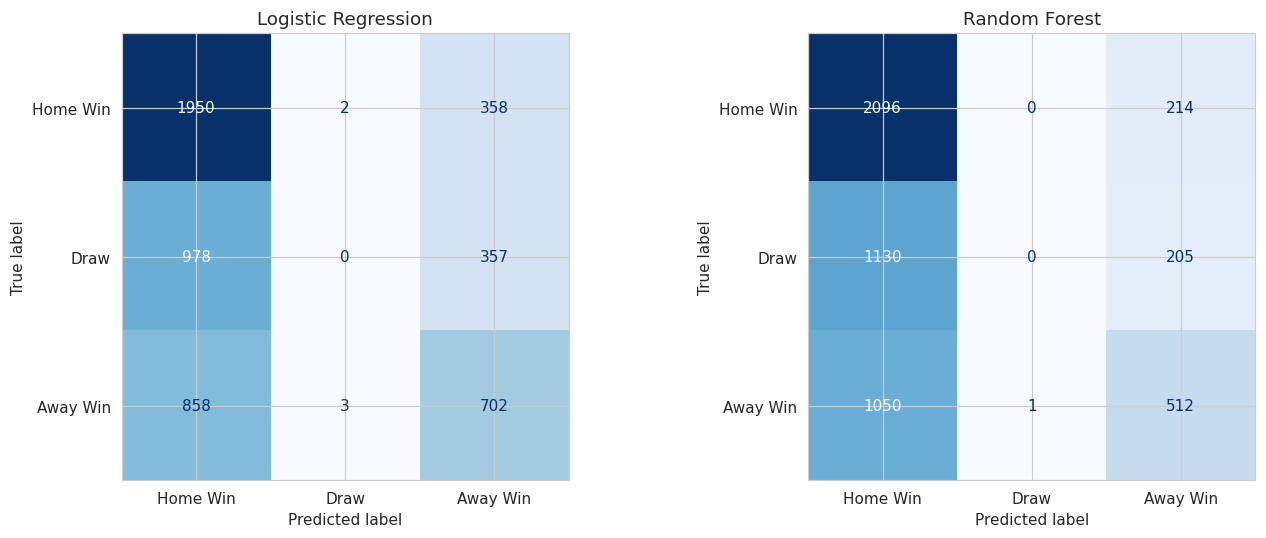

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, (name, model) in zip(axes, [('Logistic Regression', log_reg), ('Random Forest', rand_forest)]):
    preds = model.predict(X_test)
    cm = confusion_matrix(y_test, preds, labels=['Home Win', 'Draw', 'Away Win'])
    disp = ConfusionMatrixDisplay(cm, display_labels=['Home Win', 'Draw', 'Away Win'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(name)

plt.tight_layout()
plt.show()


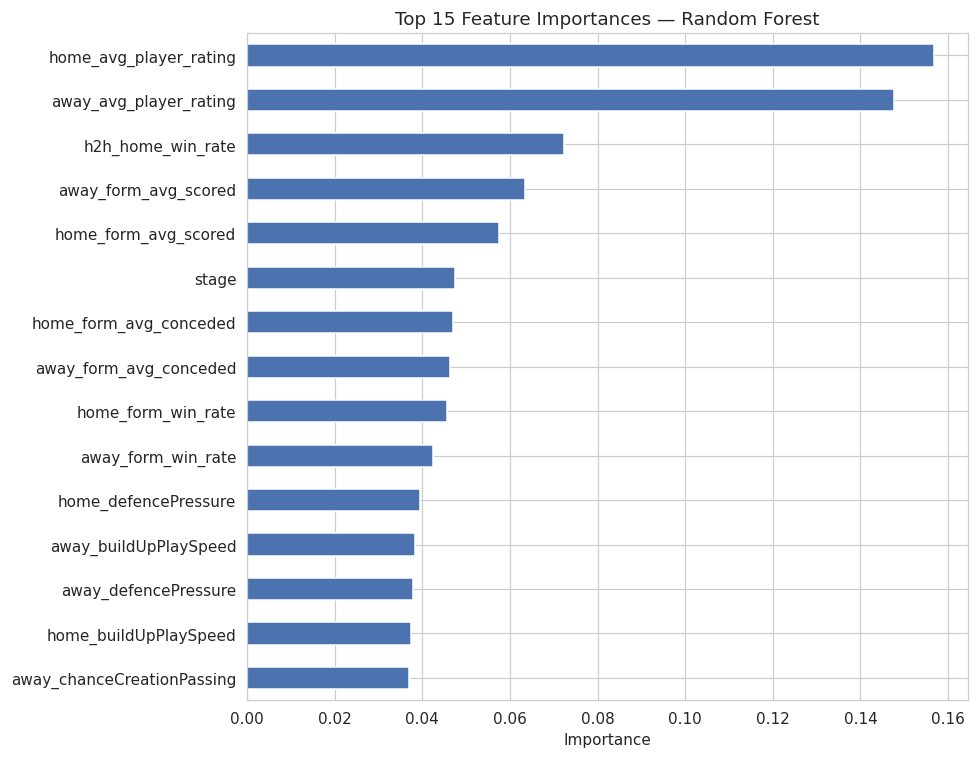

In [40]:
importances = rand_forest.named_steps['model'].feature_importances_
feature_names = (
    numeric_features +
    list(rand_forest.named_steps['preprocess'].named_transformers_['cat'].get_feature_names_out(categorical_features))
)

feat_importance = pd.Series(importances, index=feature_names).sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(9, 7))
feat_importance.sort_values().plot(kind='barh', ax=ax, color='#4C72B0')
ax.set_title('Top 15 Feature Importances — Random Forest')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()


## 26. Summary & Next Steps

**What this notebook produced:**
- A fully reproducible, Kaggle-API-driven pipeline from raw SQLite to a clean, analysis-ready dataset
- Missing-value handling tailored per table (median/mode imputation, or dropping high-missingness columns)
- Engineered match outcome labels (`home_win`, `away_win`, `draw`, `goal_difference`)
- Event-level features parsed out of embedded XML (possession, shots on/off target, fouls, cards)
- A single consolidated `soccer_match_master.csv`, ready for exploratory analysis or predictive modeling
- Exploratory analysis of goal distributions, monthly/seasonal trends, team- and league-level time series, and top-performer and outlier visualizations
- A leakage-free, pre-match feature set: team playing style, rolling team form, head-to-head history, and starting-XI player quality
- Logistic Regression and Random Forest models predicting `match_result`, evaluated with a time-based split against a naive baseline

**Suggested next steps:**
1. Tune hyperparameters (e.g. `RandomizedSearchCV`) and try gradient-boosted trees (XGBoost/LightGBM) for a stronger benchmark
2. Add betting-market odds columns (already present in `Match`) as a strong, well-calibrated reference feature
3. Try class-balancing techniques (class weights, SMOTE) to see if draw recall specifically improves
4. Backtest the model season-by-season instead of a single split, to check how stable performance is over time
